# **IMPORT LIBRARY**

In [ ]:
# Import library dasar
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # untuk 3D plot
# Agar plot tampil rapi
plt.rcParams['figure.figsize' ] = (8, 6)

# **LOAD DATASET CANCER**

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Machine Learning/Pertemuan12/Tugas/data/cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# **EKSPLORASI AWAL DATASET (EDA) CANCER**

In [ ]:
# Informasi umum dataset
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perime

In [ ]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
# Cek missing value
print("\nCek Missing Value:")
df.isnull().sum()


Cek Missing Value:


,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
# Cek data duplikat
print("\nCek Data Duplikat:")
df.duplicated().sum()


Cek Data Duplikat:


np.int64(0)

In [ ]:
print("Distribusi kelas target:")
df['diagnosis'].value_counts()

Distribusi kelas target:


,count
diagnosis,
B,357
M,212


In [ ]:
svm = SVC(kernel='rbf', gamma='scale', class_weight='balanced')

# **DATA CLEANING**

In [ ]:
# Menghapus kolom yang tidak relevan
df = df.drop(columns=['id', 'Unnamed: 32'])

# Encoding label diagnosis (M = 1, B = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# **PEMISAHAN FITUR DAN LABEL**

In [ ]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("\nBentuk X:", X.shape)
print("Bentuk y:", y.shape)


Bentuk X: (569, 30)
Bentuk y: (569,)


# **Pembagian Data Latih dan Data Uji (Train-Test Split)**

In [ ]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

Shape X_train: (455, 30)
Shape X_test : (114, 30)


# **STANDARDISASI DATA**

In [ ]:
# Standardisasi (mean=0, std=1)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)      # fit + transform pada data train
X_test_scaled = scaler. transform(X_test)           # hanya transform pada data test

X_train_scaled[:3]

array([[ 5.18558727e-01,  8.91825791e-01,  4.24631702e-01,
         3.83925436e-01, -9.74743706e-01, -6.89771505e-01,
        -6.88586446e-01, -3.98175254e-01, -1.03915470e+00,
        -8.25056321e-01, -1.09317755e-01, -5.59755400e-02,
        -2.10096206e-01, -1.59132582e-02, -1.00518399e+00,
        -9.11941990e-01, -6.62815884e-01, -6.52561081e-01,
        -7.01889114e-01, -2.75393571e-01,  5.79797697e-01,
         1.31324246e+00,  4.66908134e-01,  4.45982711e-01,
        -5.96154777e-01, -6.34722227e-01, -6.10227299e-01,
        -2.35743918e-01,  5.45663235e-02,  2.18367276e-02],
       [-5.16364088e-01, -1.63971029e+00, -5.41348716e-01,
        -5.42961327e-01,  4.76219058e-01, -6.31833818e-01,
        -6.04281166e-01, -3.03074908e-01,  5.21543093e-01,
        -4.54522896e-01, -6.04377961e-01, -1.00104604e+00,
        -5.85429002e-01, -4.93453793e-01,  4.03212009e-01,
        -7.68173276e-01, -4.79187222e-01,  1.14508478e-01,
        -1.42950761e-01, -5.77397732e-01, -5.82458953e-

# **Penerapan Model SVM tanpa PCA (Baseline Model)**

In [ ]:
# Inisialisasi model SVM (baseline, tanpa PCA)
svm_no_pca = SVC(
    kernel='rbf',
    gamma='scale',
    class_weight='balanced'  # opsional, tapi aman
)

# Training model menggunakan data train yang sudah distandarisasi
svm_no_pca.fit(X_train_scaled, y_train)

# Prediksi data test
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

# Evaluasi performa model
print("Akurasi SVM Tanpa PCA:", accuracy_score(y_test, y_pred_no_pca))
print("\nClassification Report (Tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca))

Akurasi SVM Tanpa PCA: 0.9824561403508771

Classification Report (Tanpa PCA):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# **Penerapan PCA (Principal Component Analysis)**

In [ ]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca :", X_test_pca.shape)

Shape X_train_pca: (455, 3)
Shape X_test_pca : (114, 3)


# **Menampilkan Variansi yang Dijelaskan oleh Setiap Komponen PCA**

In [ ]:
# Variansi yang dijelaskan oleh tiap komponen
explained_var = pca.explained_variance_ratio_
print("Explained Variance Ratio tiap komponen:", explained_var)
print("Total variansi yang dijelaskan 3 komponen pertama:", explained_var.sum())

Explained Variance Ratio tiap komponen: [0.44593522 0.18545255 0.09584641]
Total variansi yang dijelaskan 3 komponen pertama: 0.7272341886241546


## **Diagram Batang Explained Variance Ratio PCA**

Memvisualisasikan kontribusi masing-masing komponen utama PCA terhadap total variansi data.

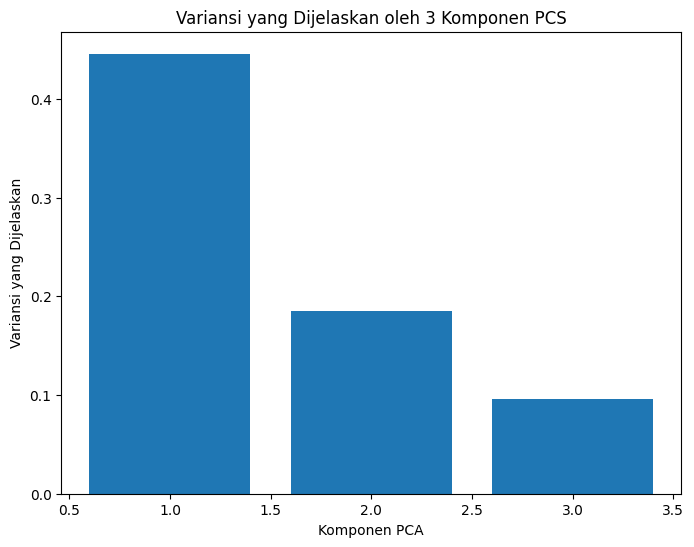

In [ ]:
plt.bar([1, 2, 3], explained_var)
plt.xlabel('Komponen PCA')
plt.ylabel('Variansi yang Dijelaskan')
plt.title('Explained Variance Ratio')
plt.title('Variansi yang Dijelaskan oleh 3 Komponen PCS')
plt.show()

# **Membangun Model SVM dengan PCA**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Inisialisasi model SVM dengan PCA
svm_pca = SVC(
    kernel='rbf',
    gamma='scale',
    class_weight='balanced'  # opsional
)

# Training model menggunakan data hasil PCA
svm_pca.fit(X_train_pca, y_train)

# Prediksi data test
y_pred_pca = svm_pca.predict(X_test_pca)

# Evaluasi performa model
print("Akurasi SVM dengan PCA:", accuracy_score(y_test, y_pred_pca))
print("\nClassification Report (dengan PCA):")
print(classification_report(y_test, y_pred_pca))

Akurasi SVM dengan PCA: 0.9385964912280702

Classification Report (dengan PCA):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



# **Visualisasi PCA dalam Ruang 3 Dimensi**

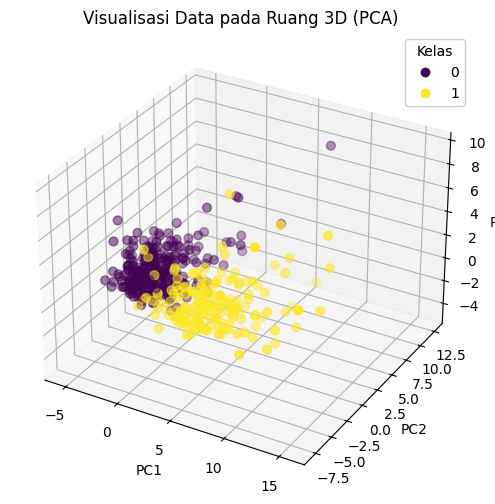

In [ ]:
# Membuat figure 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot PCA 3D
scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    cmap='viridis',
    s=40
)

# Label sumbu
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Judul
ax.set_title('Visualisasi Data pada Ruang 3D (PCA)')

# Legend otomatis
legend = ax.legend(*scatter.legend_elements(), title="Kelas")
ax.add_artist(legend)

plt.show()

# **Perbandingan Model SVM Tanpa PCA dan Dengan PCA**

In [30]:
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (3 Komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': [None, explained_var.sum()]
})

comparison

,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM Tanpa PCA,30,0.973684,NaN
1,SVM Dengan PCA (3 Komponen),3,0.956140,0.727234


# **Visualisasi Grafik**

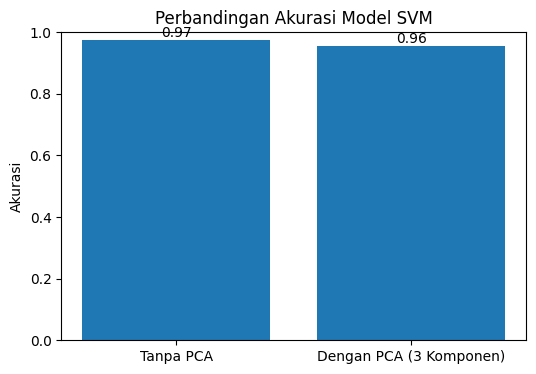

In [31]:
plt.figure(figsize=(6,4))
plt.bar(['Tanpa PCA', 'Dengan PCA (3 Komponen)'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi Model SVM' )
plt.ylabel('Akurasi')
plt.ylim(0, 1)
for i, v in enumerate([acc_no_pca, acc_pca]):
  plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()